# N2 + H2O (gas, condensate)

Hajime Kawahara 2025/11/16

In this notebook, we adopt N2 as the background atmosphere and water as a species that can exist either in the gas phase or as a condensate. We then examine how the phase of water is determined through Gibbs free‐energy minimization.

In [1]:
from jax import config
config.update("jax_enable_x64", True)

We assume N2+H2O (gas, water, ice) system using fastchem/fastchem_cond presets. 

In [2]:
from exogibbs.presets.fastchem_cond import chemsetup as condsetup
cond = condsetup()
from exogibbs.presets.fastchem import chemsetup as gassetup
gas = gassetup()


fastchem_cond presets in ExoGibbs
number of species: 186 elements: 28 molecules: 186
fastchem presets in ExoGibbs
number of species: 523 elements: 28 molecules: 495


In [3]:
gas_species = list(gas.species)
gas_system = ['H2O1', 'N2']
index_h2o_gas = gas_species.index('H2O1')  
index_n2_gas = gas_species.index('N2')

cond_species = list(cond.species)
cond_system = ['H2O(s,l)']
index_h2o_cond = cond_species.index('H2O(s,l)')  

In [4]:
import numpy as np
from exogibbs.thermo.stoichiometry import build_formula_matrix
from exogibbs.utils.nameparser import set_elements_from_components
from exogibbs.utils.nameparser import generate_components_from_formula_list

components_g = generate_components_from_formula_list(gas_system)
elements = np.array(["H", "N", "O"])  # fixed ordering for this notebook
formula_matrix_gas = build_formula_matrix(components_g, elements)

print("Formula matrix (gas):")
print(formula_matrix_gas)

components_c = generate_components_from_formula_list(cond_system)
formula_matrix_cond = build_formula_matrix(components_c, elements)

print("Formula matrix (cond):")
print(formula_matrix_cond)



Formula matrix (gas):
[[2 0]
 [0 2]
 [1 0]]
Formula matrix (cond):
[[2]
 [0]
 [1]]


This setting yields rank(Ac, Ag) < |b_element| because formula_matrix_gas[:,0] = formula_matrix_cond[:,0]. We need to redefine the formulation using the matrix contraction. 

In [5]:
from exogibbs.thermo.stoichiometry import contract_formula_matrix
formula_matrix_gas_eff, formula_matrix_cond_eff, indep_element_mask = contract_formula_matrix(formula_matrix_gas, formula_matrix_cond)
elements_eff =elements[indep_element_mask]

print("Formula matrix (gas):")
print(formula_matrix_gas_eff)
print("Formula matrix (cond):")
print(formula_matrix_cond_eff)
print("independent elements:")
print(elements_eff)


Contraction of the system performed.
Formula matrix (gas):
[[2 0]
 [0 2]]
Formula matrix (cond):
[[2]
 [0]]
independent elements:
['H' 'N']


Output the reference-state value of ( $h = \mu / (RT)$ ) at temperature ( T ).


In [6]:
def h2o_cond_h_values(T): 
    return  cond.hvector_func(T)[index_h2o_cond]

def h2o_gas_h_values(T, p, nH2O, nN2):
    ntot = nH2O + nN2
    return  gas.hvector_func(T)[index_h2o_gas] + np.log(p*nH2O/ntot)

def n2_gas_h_values(T, p, nH2, nN2):
    ntot = nH2 + nN2
    return  gas.hvector_func(T)[index_n2_gas] + np.log(p*nN2/ntot)

We have the analytic solution this system, in fact...

In [7]:
import jax.numpy as jnp
def nh2o_analytic(p, delta_hvector, n_gas_max, n_bkgd_max):
    k = jnp.exp(- delta_hvector)
    nast = n_bkgd_max * k / (p - k)
    return jnp.min(jnp.array([n_gas_max, nast]))
        


If there exists an nH2O for which the chemical potential of the gas equals that of the condensate, the gas and condensate coexist in a gas–condensate equilibrium. If no such value exists, the chemical potential of the gas is always lower and only the gas is present.

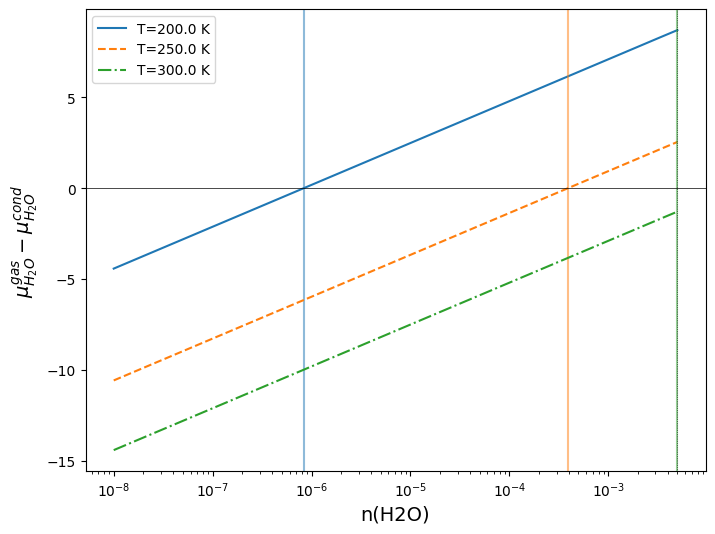

In [8]:
import matplotlib.pyplot as plt
bN = 0.99
bH = 0.01
p = 1.0 # bar
        

nh2os = np.logspace(-8, np.log10(bH/2), 1000)
def plotfig():
    fig = plt.figure(figsize=(8,6))
    for i, T in enumerate([200.0, 250.0, 300.0]):
        plt.plot(nh2os, h2o_gas_h_values(T, p, nh2os, bN/2)- h2o_cond_h_values(T), label='T='+str(T)+" K", ls=['solid', '--', '-.'][i])
        # analytic solution    
        dh = gas.hvector_func(T)[index_h2o_gas] - cond.hvector_func(T)[index_h2o_cond]
        plt.axvline(nh2o_analytic(p, dh, bH/2, bN/2), color='C'+str(i), alpha=0.5)
    
    plt.axhline(0.0, color='k', lw=0.5)
    plt.axvline(bH/2, color='k', lw=0.5, ls='dotted')
    
    
    plt.xscale("log")
    plt.ylabel("$\mu_{H_2O}^{gas} - \mu_{H_2O}^{cond}$", fontsize=14)
    plt.xlabel("n(H2O)", fontsize=14)
    plt.legend()
    return fig

fig = plotfig()
plt.show()


The amount of nH2O can also be verified directly by minimizing the total Gibbs energy.

In [9]:
import numpy as np
def gibbs_energy(T,p, nN2, nH2O, mH2O):
    mu_h2o = h2o_gas_h_values(T, p, nH2O, nN2)
    mu_n2 = n2_gas_h_values(T, p, nH2O, nN2)
    return h2o_cond_h_values(T)*mH2O + mu_h2o*nH2O + mu_n2*nN2

In [10]:

def gibbs_given(nh2o,T,p=1.0):
    return gibbs_energy(T, p, bN/2, nh2o, bH/2 - nh2o)
nmh2o = 0.01


Text(0, 0.5, 'Gibbs energy (relative)')

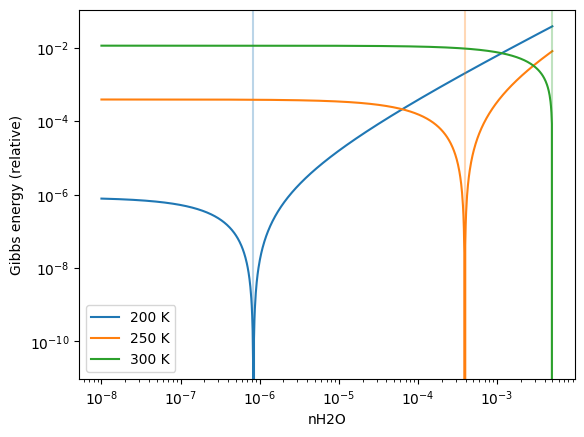

In [11]:
nh2os = np.logspace(-8,np.log10(bH/2),1000)
for i, T in enumerate([200,250,300]):
    plt.plot(nh2os, gibbs_given(nh2os,T) - np.nanmin(gibbs_given(nh2os,T)), label=str(T)+" K")
    dh =  gas.hvector_func(T)[index_h2o_gas] - cond.hvector_func(T)[index_h2o_cond]
    plt.axvline(nh2o_analytic(p, dh, bH/2, bN/2), color='C'+str(i), alpha=0.3)
    
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("nH2O")
plt.ylabel("Gibbs energy (relative)")
#plt.xscale("log")

Derive the minimum using a grid search.

In [12]:
def nh2o_gibbs_min(T,p=1.0):
    i = np.nanargmin(gibbs_given(nh2os,T,p))
    return nh2os[i]

In [13]:
from tqdm import tqdm

Parr = np.logspace(-3, 3, 25)
Tarr = np.linspace(100, 500, 25)

nh2os_arr = []
for p in tqdm(Parr):
    mastarr_t = []
    for T in Tarr:
        mastarr_t.append(nh2o_gibbs_min(T, p))
    nh2os_arr.append(mastarr_t)
nh2os_arr = np.array(nh2os_arr)

100%|██████████| 25/25 [00:01<00:00, 18.31it/s]


In [14]:
from exojax.atm.psat import psat_water_AM01 
Psat_arr = psat_water_AM01(Tarr)

The boundary at which a condensate forms can also be determined by dividing the saturation pressure by the maximum partial pressure of H2O gas.

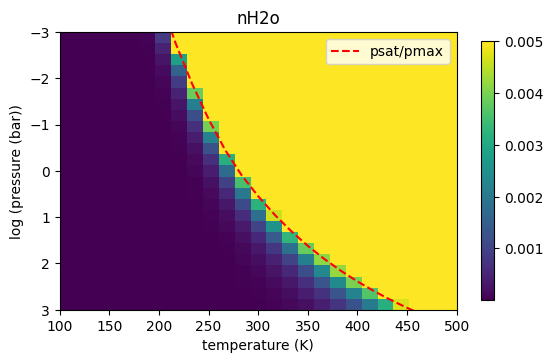

In [15]:
pmax = (bH/2)/(bH/2 + bN/2)  # maximum possible nH2O
fig = plt.figure()
ax = fig.add_subplot(111)
c = ax.imshow(nh2os_arr, extent=(Tarr[0],Tarr[-1],np.log10(Parr[-1]),np.log10(Parr[0])))
plt.plot(Tarr, np.log10(Psat_arr/pmax), color='red', linestyle='dashed', label='psat/pmax')
ax.set_ylim(np.log10(Parr[0]), np.log10(Parr[-1]))
plt.colorbar(c, shrink=0.7)
ax.set_aspect(0.7/ax.get_data_ratio())
plt.gca().invert_yaxis()
ax.set_xlabel("temperature (K)")
ax.set_ylabel("log (pressure (bar))")
ax.set_title("nH2o")
plt.legend()
plt.show()
plt.close()

## minimization using minimize_gibbs_cond_core

In [16]:
from exogibbs.optimize.minimize_cond import minimize_gibbs_cond_core
import jax.numpy as jnp
from exogibbs.api.chemistry import ThermoState

from exogibbs.optimize.core import compute_ln_normalized_pressure


In [67]:

# Thermodynamic conditions


P = 1.0  # bar
Pref = 1.0  # bar, reference pressure
ln_normalized_pressure = compute_ln_normalized_pressure(P, Pref)

# Initial guess for log number densities
epsilon = -3.0
epsilon_crit = -20.0
bN = 0.99
bH = 0.01

b_ref = jnp.array([bH,bN]) #bH,bN
    
ln_nk = jnp.log(jnp.ones(formula_matrix_gas_eff.shape[1])* jnp.array([bH/4.0, bN/2.0]) ) # log(n_species)
ln_mk = jnp.log(jnp.ones(formula_matrix_cond_eff.shape[1])*bH/4.0) 
ln_ntot = jnp.log(jnp.sum(jnp.exp(ln_nk)) ) # log(total number density)



def hvector_cond_func(T): 
    return  jnp.array([cond.hvector_func(T)[index_h2o_cond]])

def hvector_func(T):
    return  jnp.array([gas.hvector_func(T)[index_h2o_gas],gas.hvector_func(T)[index_n2_gas]])


for i, temperature in enumerate([300.0]):

    #analytic solution
    dh =  gas.hvector_func(temperature)[index_h2o_gas] - cond.hvector_func(temperature)[index_h2o_cond]
    nh2_ana = nh2o_analytic(P, dh, bH/2, bN/2)

    #PD-IPM
    nkpath=[]
    mkpath=[]
    eppath=[]
    
    thermo_state = ThermoState(
        temperature=temperature,
        ln_normalized_pressure=ln_normalized_pressure,
        element_vector=b_ref,
    )



    while epsilon > epsilon_crit:
        epsilon = epsilon - 1.0
    
        ln_nk, ln_mk, ln_ntot, counter = minimize_gibbs_cond_core(
            thermo_state,
            ln_nk_init=ln_nk,
            ln_mk_init=ln_mk,
            ln_ntot_init=ln_ntot,
            formula_matrix=formula_matrix_gas_eff,
            formula_matrix_cond=formula_matrix_cond_eff,
            hvector_func=hvector_func,
            hvector_cond_func=hvector_cond_func,
            epsilon=epsilon,  ### new argument
            residual_crit=1.0e-10,
            max_iter=1000,
        )

        nkpath.append(jnp.exp(ln_nk)[0])
        mkpath.append(jnp.exp(ln_mk)[0])
        eppath.append(epsilon)
        print("Optimization:", jnp.exp(ln_nk)[0], "Analytic:",nh2_ana, "counter=", counter, "epsilon=", epsilon)
    



Optimization: 0.00035057991578358173 Analytic: 0.005 counter= 169 epsilon= -4.0
Optimization: 0.0019640727770410854 Analytic: 0.005 counter= 169 epsilon= -5.0
Optimization: 0.003494386543803605 Analytic: 0.005 counter= 161 epsilon= -6.0
Optimization: 0.004360792002203278 Analytic: 0.005 counter= 151 epsilon= -7.0
Optimization: 0.004750003316841123 Analytic: 0.005 counter= 141 epsilon= -8.0
Optimization: 0.004905787521636202 Analytic: 0.005 counter= 132 epsilon= -9.0
Optimization: 0.004965023821360986 Analytic: 0.005 counter= 122 epsilon= -10.0
Optimization: 0.004987089290713894 Analytic: 0.005 counter= 113 epsilon= -11.0
Optimization: 0.004995244440312979 Analytic: 0.005 counter= 103 epsilon= -12.0
Optimization: 0.0049982496951085625 Analytic: 0.005 counter= 94 epsilon= -13.0
Optimization: 0.004999355960796761 Analytic: 0.005 counter= 84 epsilon= -14.0
Optimization: 0.004999763030736392 Analytic: 0.005 counter= 75 epsilon= -15.0
Optimization: 0.004999912793042251 Analytic: 0.005 counte

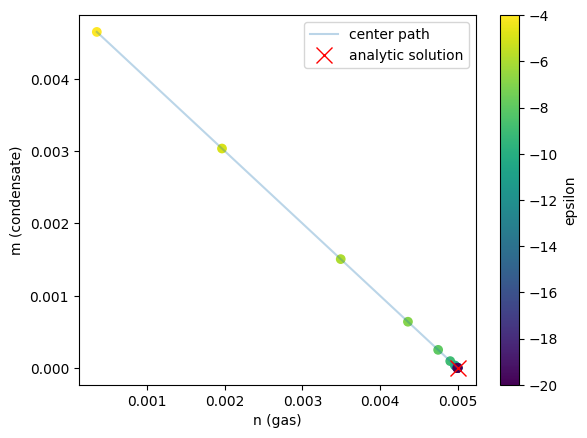

In [69]:
%matplotlib inline
import matplotlib.pyplot as plt
nkpath = jnp.array(nkpath)
mkpath = jnp.array(mkpath)
eppath = jnp.array(eppath)
c = plt.scatter(nkpath, mkpath, c=eppath, cmap='viridis')
cb = plt.colorbar(c)
cb.set_label('epsilon')
plt.plot(nkpath, mkpath, alpha=0.3, label="center path")
plt.plot(nh2_ana, bH/2 - nh2_ana, "rx", markersize=12, label="analytic solution")
#plt.xscale("log")
#plt.yscale("log")
plt.legend()
plt.xlabel("n (gas)")
plt.ylabel("m (condensate)")
plt.show()



In [51]:
jnp.log(0.00039)

Array(-7.84936382, dtype=float64, weak_type=True)